In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv('/content/creditcard.csv')

In [35]:
# 데이터 구조 파악
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [36]:
# 사기 결제와 정상 결제 구분, 사기 결제는 Class가 1이고, 정상 결제는 Class가 0이다.
df_T = df[df['Class'] == 1]
print(df_T)
df_F = df[df['Class'] == 0]
print(df_F)

            Time        V1        V2        V3        V4        V5        V6  \
541        406.0 -2.312227  1.951992 -1.609851  3.997906 -0.522188 -1.426545   
623        472.0 -3.043541 -3.157307  1.088463  2.288644  1.359805 -1.064823   
4920      4462.0 -2.303350  1.759247 -0.359745  2.330243 -0.821628 -0.075788   
6108      6986.0 -4.397974  1.358367 -2.592844  2.679787 -1.128131 -1.706536   
6329      7519.0  1.234235  3.019740 -4.304597  4.732795  3.624201 -1.357746   
...          ...       ...       ...       ...       ...       ...       ...   
279863  169142.0 -1.927883  1.125653 -4.518331  1.749293 -1.566487 -2.010494   
280143  169347.0  1.378559  1.289381 -5.004247  1.411850  0.442581 -1.326536   
280149  169351.0 -0.676143  1.126366 -2.213700  0.468308 -1.120541 -0.003346   
281144  169966.0 -3.113832  0.585864 -5.399730  1.817092 -0.840618 -2.943548   
281674  170348.0  1.991976  0.158476 -2.583441  0.408670  1.151147 -0.096695   

              V7        V8        V9  .

In [37]:
# 사기 결제 각 column별 분포 확인
print(df_T.describe())

                Time          V1          V2          V3          V4  \
count     492.000000  492.000000  492.000000  492.000000  492.000000   
mean    80746.806911   -4.771948    3.623778   -7.033281    4.542029   
std     47835.365138    6.783687    4.291216    7.110937    2.873318   
min       406.000000  -30.552380   -8.402154  -31.103685   -1.313275   
25%     41241.500000   -6.036063    1.188226   -8.643489    2.373050   
50%     75568.500000   -2.342497    2.717869   -5.075257    4.177147   
75%    128483.000000   -0.419200    4.971257   -2.276185    6.348729   
max    170348.000000    2.132386   22.057729    2.250210   12.114672   

               V5          V6          V7          V8          V9  ...  \
count  492.000000  492.000000  492.000000  492.000000  492.000000  ...   
mean    -3.151225   -1.397737   -5.568731    0.570636   -2.581123  ...   
std      5.372468    1.858124    7.206773    6.797831    2.500896  ...   
min    -22.105532   -6.406267  -43.557242  -41.044261  

In [38]:
# 정상 결제 각 column별 분포 확인
print(df_F.describe())

                Time             V1             V2             V3  \
count  284315.000000  284315.000000  284315.000000  284315.000000   
mean    94838.202258       0.008258      -0.006271       0.012171   
std     47484.015786       1.929814       1.636146       1.459429   
min         0.000000     -56.407510     -72.715728     -48.325589   
25%     54230.000000      -0.917544      -0.599473      -0.884541   
50%     84711.000000       0.020023       0.064070       0.182158   
75%    139333.000000       1.316218       0.800446       1.028372   
max    172792.000000       2.454930      18.902453       9.382558   

                  V4             V5             V6             V7  \
count  284315.000000  284315.000000  284315.000000  284315.000000   
mean       -0.007860       0.005453       0.002419       0.009637   
std         1.399333       1.356952       1.329913       1.178812   
min        -5.683171    -113.743307     -26.160506     -31.764946   
25%        -0.850077      -0.6893

In [39]:
# V가 판단 요소라 보고 각 V별 평균 산정
for i in range(28):
  print(f'사기 {i+1}번째: {df_T['V' + str(i + 1)].mean()}')
for j in range(28):
  print(f'평범 {j+1}번째: {df_F['V' + str(j + 1)].mean()}')

사기 1번째: -4.771948441479082
사기 2번째: 3.6237781019822806
사기 3번째: -7.0332810485965584
사기 4번째: 4.542029104423092
사기 5번째: -3.151224885936005
사기 6번째: -1.3977367105923515
사기 7번째: -5.5687310837427395
사기 8번째: 0.5706358952962376
사기 9번째: -2.581122921702995
사기 10번째: -5.676882870194368
사기 11번째: 3.800172911374607
사기 12번째: -6.259393036190131
사기 13번째: -0.10933381708278403
사기 14번째: -6.971722894107602
사기 15번째: -0.09292874691208501
사기 16번째: -4.139945699092808
사기 17번째: -6.665836399449663
사기 18번째: -2.2463081339714064
사기 19번째: 0.680659303475429
사기 20번째: 0.3723193957714717
사기 21번째: 0.7135883526687006
사기 22번째: 0.014048882140121373
사기 23번째: -0.04030796594836943
사기 24번째: -0.10513030543948289
사기 25번째: 0.041448887262827076
사기 26번째: 0.05164812556245366
사기 27번째: 0.17057479224418592
사기 28번째: 0.0756672906457746
평범 1번째: 0.00825773748556368
평범 2번째: -0.006270857415807067
평범 3번째: 0.01217091703184535
평범 4번째: -0.00785986782046519
평범 5번째: 0.005453115888647496
평범 6번째: 0.0024187484361073517
평범 7번째: 0.009636549929484083
평범 8번째:

In [40]:
# 사기 결제와 정상 결제에서 어떤게 차이가 가장 커서 원인이 되는지 궁금하여 두 개의 평균의 차이 파악
for i in range(28):
  print(f'V{i+1} 절댓값 차이: {abs(df_T['V' + str(i + 1)].mean()) - abs(df_F['V' + str(i + 1)].mean())}')

V1 절댓값 차이: 4.763690703993518
V2 절댓값 차이: 3.6175072445664735
V3 절댓값 차이: 7.021110131564713
V4 절댓값 차이: 4.534169236602627
V5 절댓값 차이: 3.1457717700473578
V6 절댓값 차이: 1.3953179621562442
V7 절댓값 차이: 5.559094533813256
V8 절댓값 차이: 0.5696484241445723
V9 절댓값 차이: 2.576656353011659
V10 절댓값 차이: 5.667059166302079
V11 절댓값 차이: 3.7935968071507857
V12 절댓값 차이: 6.248561313017575
V13 절댓값 차이: 0.10914461764552268
V14 절댓값 차이: 6.959658501923225
V15 절댓값 차이: 0.09276793603864487
V16 절댓값 차이: 4.132781626553708
V17 절댓값 차이: 6.654301336197534
V18 절댓값 차이: 2.2424209539003086
V19 절댓값 차이: 0.6794814395663507
V20 절댓값 차이: 0.3716751063645837
V21 절댓값 차이: 0.7123535058631751
V22 절댓값 차이: 0.014024570900781061
V23 절댓값 차이: 0.0402382140209415
V24 절댓값 차이: 0.10494838007403436
V25 절댓값 차이: 0.04137716099958679
V26 절댓값 차이: 0.05155874977230454
V27 절댓값 차이: 0.1702796168303518
V28 절댓값 차이: 0.07553635029089442


In [41]:
# V 뿐만 아닌 다른 요소도 확인하기 위해 시간의 평균 비교
print(df_T['Time'].mean())
print(df_F['Time'].mean())

80746.80691056911
94838.20225805884


In [42]:
print(df_T['Amount'].mean())
print(df_F['Amount'].mean())

122.21132113821139
88.29102242231328


In [43]:
# 학습을 위해 사기 결제에서 정답인 Class를 뺀 test 생성
test = df_T.loc[:, (df_T.columns != 'Class')]
print(test.head())

        Time        V1        V2        V3        V4        V5        V6  \
541    406.0 -2.312227  1.951992 -1.609851  3.997906 -0.522188 -1.426545   
623    472.0 -3.043541 -3.157307  1.088463  2.288644  1.359805 -1.064823   
4920  4462.0 -2.303350  1.759247 -0.359745  2.330243 -0.821628 -0.075788   
6108  6986.0 -4.397974  1.358367 -2.592844  2.679787 -1.128131 -1.706536   
6329  7519.0  1.234235  3.019740 -4.304597  4.732795  3.624201 -1.357746   

            V7        V8        V9  ...       V20       V21       V22  \
541  -2.537387  1.391657 -2.770089  ...  0.126911  0.517232 -0.035049   
623   0.325574 -0.067794 -0.270953  ...  2.102339  0.661696  0.435477   
4920  0.562320 -0.399147 -0.238253  ... -0.430022 -0.294166 -0.932391   
6108 -3.496197 -0.248778 -0.247768  ... -0.171608  0.573574  0.176968   
6329  1.713445 -0.496358 -1.282858  ...  0.009061 -0.379068 -0.704181   

           V23       V24       V25       V26       V27       V28  Amount  
541  -0.465211  0.320198  0.0

In [44]:
# 정상 결제에서 Class를 제거
test2 = df_F.loc[:, (df_F.columns != 'Class')]
print(test2.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V20       V21       V22       V23       V24  \
0  0.098698  0.363787  ...  0.251412 -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425  ... -0.069083 -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  ...  0.524980  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024  ... -0.208038 -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  ...  0.408542 -0.009431  0.798278 -0.137458  0.141267   

        V25       V26       V27 

In [45]:
print(df['Class'].isnull().sum())

0


In [46]:
df = df.dropna(subset=['Class'])

In [47]:
# 위에서 했던 방식으로 하면 2개를 합치기 힘들어서 train_test_split을 이용하여 학습 데이터와 검증 데이터로 데이터를 분할함
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['Class'], random_state=42)
X_train = train_df.drop('Class', axis=1)
y_train = train_df['Class']
X_val = val_df.drop('Class', axis=1)
y_val = val_df['Class']

In [48]:
# 학습과 검증 데이터에서 사기 결제 비율이 유사한지 확인
print(f'{len(train_df[train_df['Class'] == 1]) / len(train_df)}')
print(f'{len(val_df[val_df['Class'] == 1]) / len(val_df)}')

0.001729245759178389
0.0017204452090867595


In [49]:
print(X_train.head())
print(y_train.head())

            Time        V1        V2        V3        V4        V5        V6  \
265518  161919.0  1.946747 -0.752526 -1.355130 -0.661630  1.502822  4.024933   
180305  124477.0  2.035149 -0.048880 -3.058693  0.247945  2.943487  3.298697   
42664    41191.0 -0.991920  0.603193  0.711976 -0.992425 -0.825838  1.956261   
198723  132624.0  2.285718 -1.500239 -0.747565 -1.668119 -1.394143 -0.350339   
82325    59359.0 -0.448747 -1.011440  0.115903 -3.454854  0.715771 -0.147490   

              V7        V8        V9  ...       V20       V21       V22  \
265518 -1.479661  1.139880  1.406819  ... -0.134435  0.076197  0.297537   
180305 -0.002192  0.674782  0.045826  ... -0.227279  0.038628  0.228197   
42664  -2.212603 -5.037523  0.000772  ...  1.280856 -2.798352  0.109526   
198723 -1.427984  0.010010 -1.118447  ... -0.490642 -0.139670  0.077013   
82325   0.504347 -0.113817 -0.044782  ... -0.275297 -0.243245 -0.173298   

             V23       V24       V25       V26       V27       V28  

In [50]:
# 학습 때 한 클래스에만 편향되지 않게 하기 위해 StandardScaler 사용
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.fit_transform(X_val)

In [51]:
# 사기 결제인지 아닌지 탐지를 하기 위해 LogisticRegression을 사용하였고, 사기 결제의 데이터가 많이 적어서 불균형을 맞추기 위해 class_weight='balanced'를 사용
model = LogisticRegression(max_iter = 2000, class_weight='balanced').fit(X_train_scaled, y_train)

In [52]:
# 일단 가장 기본인 정확도 점수를 확인 하니 둘 다 높게 나왔음
print(f'train score = {model.score(X_train_scaled, y_train)}')
print(f'val score = {model.score(X_val_scaled, y_val)}')

train score = 0.976128508415809
val score = 0.9755275446789088


In [53]:
# credit card 사기는 사기인데 정상이라 탐지하는 FN을 줄이는게 도움이 된다고 보아 이와 연관된 recall을 높이려고 함

In [54]:
y_pred = model.predict(X_val_scaled)

In [55]:
# Recall 점수가 0.918이어서 이를 높이고자 판단함
print(f'recall: {recall_score(y_val, y_pred, zero_division=0)}')
print(f'precision: {precision_score(y_val, y_pred, zero_division=0)}')
print(f'f1-score: {f1_score(y_val, y_pred)}')

recall: 0.9183673469387755
precision: 0.06097560975609756
f1-score: 0.11435832274459974


In [56]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



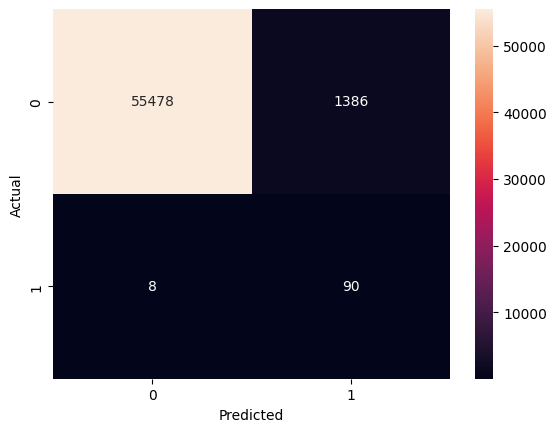

In [57]:
# 분석을 위해 confusion_matrix를 사용해 전체에서 얼마나 놓쳤는지 확인
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [92]:
# Recall을 줄이기 위해 threshold를 0.825로 조정
y_probs = model.predict_proba(X_val_scaled)[:, 1]
threshold = 0.224
y_pred_new = (y_probs > threshold).astype(int)
print(classification_report(y_val.values, y_pred_new))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     56864
           1       0.02      0.93      0.04        98

    accuracy                           0.92     56962
   macro avg       0.51      0.92      0.50     56962
weighted avg       1.00      0.92      0.95     56962



In [93]:
# Recall 점수가 0.918에서 0.928로 증가하여 채택
print(f'recall: {recall_score(y_val, y_pred_new, zero_division=0)}')
print(f'precision: {precision_score(y_val, y_pred_new, zero_division=0)}')
print(f'f1-score: {f1_score(y_val, y_pred_new)}')

recall: 0.9285714285714286
precision: 0.018848384424192212
f1-score: 0.036946812829882256


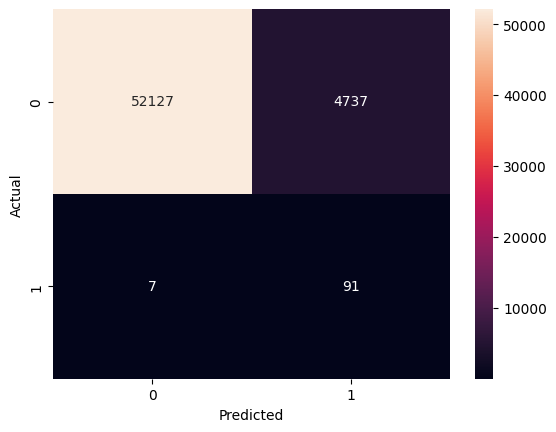

In [94]:
# Recall 점수가 제대로인지 확인하기 위해 confusion_matrix로 비율 확인
cm = confusion_matrix(y_val.values, y_pred_new)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [61]:
# FN은 1개가 줄었지만 FP가 너무 많이 증가함
# 사기 결제 데이터가 너무 적어서 어쩔 수 없는건지, FP도 줄일 수 있는 방법이 필요해 보임

In [62]:
print("정답(y_val) 상위 10개:", y_val.values[:10])
print("확률(y_probs) 상위 10개:", y_probs[:10])

정답(y_val) 상위 10개: [0 0 0 0 0 0 0 0 0 0]
확률(y_probs) 상위 10개: [5.31256487e-03 6.59345762e-02 1.15806314e-04 1.50801932e-02
 9.43907218e-01 1.29398588e-02 8.18881023e-04 2.59497618e-02
 6.46804800e-02 4.54111379e-03]
